# Notebook 04 - Machine Learning: Baseline vs Graph-Enriched Prediction

## Business Objective

Predict whether a supply chain order will be delayed using:
- Operational supply-chain features
- Graph-derived features from Neo4j

Two models are compared:
1. **Baseline (S5)** — operational features + degree (from Neo4j Cypher)
2. **Enriched (S6)** — same features + PageRank + community (from GDS, computed in Notebook 03)




## 0. Imports

In [3]:
import os

os.chdir(r"C:\Users\Lenovo\OneDrive\Desktop\BI_Data_and_AI_Capstone_Project\BigData_and_BI_CapstoneProject")

print(os.getcwd())

C:\Users\Lenovo\OneDrive\Desktop\BI_Data_and_AI_Capstone_Project\BigData_and_BI_CapstoneProject


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neo4j import GraphDatabase

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

CLEAN_OUTPUT_DIR = "data/clean"

uri      = "bolt://localhost:7687"
username = "neo4j"
password = "Arya@189"

driver = GraphDatabase.driver(uri, auth=(username, password))

def run_query(query):
    with driver.session() as session:
        result = session.run(query)
        return [record.data() for record in result]

## Step 1 - Extract Degree Features from Neo4j via Cypher

The degree feature is pulled LIVE from Neo4j — not from a pre-saved CSV.



In [5]:
# # Extract degree, out_degree, in_degree from Neo4j
# # OPTIONAL MATCH keeps isolated Order nodes (degree 0) in the result

# degree_raw = run_query("""
# MATCH (n:Order)
# OPTIONAL MATCH (n)-[r]-()
# RETURN n.id          AS order_id,
#        COUNT(r)      AS degree,
#        COUNT { (n)-[]->() } AS out_degree,
#        COUNT { (n)<-[]-() } AS in_degree
# """)

# df_degree = pd.DataFrame(degree_raw)

# print("Degree features shape:", df_degree.shape)
# df_degree.head()

degree_raw = run_query("""
MATCH (n:Order)

OPTIONAL MATCH (n)-[r]-()

RETURN
    n.id AS order_id,
    COUNT(r) AS degree,
    COUNT { (n)-[]->() } AS out_degree,
    COUNT { (n)<-[]-() } AS in_degree
""")

df_degree = pd.DataFrame(degree_raw)

print("Degree features shape:", df_degree.shape)
df_degree.head()

Degree features shape: (65752, 4)


,order_id,degree,out_degree,in_degree
0,77202,4,3,1
1,75939,4,3,1
2,75938,4,3,1
3,75937,4,3,1
4,75936,4,3,1


## Step 2 - Load Cleaned Supply Chain Dataset

In [6]:
main_df = pd.read_csv(f"{CLEAN_OUTPUT_DIR}/merged_df.csv")

print("Main dataset shape:", main_df.shape)
print("Columns:", main_df.columns.tolist())
main_df.head()

Main dataset shape: (114187, 55)
Columns: ['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,delay,late_flag
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class,-1,0
1,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class,-1,0
2,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class,-2,0
3,TRANSFER,6,4,18.580000,294.980011,Shipping canceled,0,73,Sporting Goods,Tonawanda,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/19/2018 11:03,Standard Class,2,1
4,DEBIT,2,1,95.180000,288.420013,Late delivery,1,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 10:42,First Class,1,1


## Step 3 - Merge Degree Features on Order Id

`Order Id` is the merge key end-to-end — it must match the `order_id` returned by the Cypher query.

After the merge, `Order Id` is set as the DataFrame index so it is carried through but never fed to the model as a feature.

In [7]:
# Align merge key types so left and right are both str
main_df["Order Id"]      = main_df["Order Id"].astype(str)
df_degree["order_id"]    = df_degree["order_id"].astype(str)

In [8]:
ml_df = main_df.merge(
    df_degree,
    how="left",
    left_on="Order Id",
    right_on="order_id"
)

ml_df[["degree", "out_degree", "in_degree"]] = (
    ml_df[["degree", "out_degree", "in_degree"]].fillna(0)
)

ml_df = ml_df.drop(columns=["order_id"], errors="ignore")

print("Merged dataset shape:", ml_df.shape)
ml_df[["Order Id", "degree", "out_degree", "in_degree"]].head()

Merged dataset shape: (114187, 58)


,Order Id,degree,out_degree,in_degree
0,77202,4,3,1
1,75937,4,3,1
2,75936,4,3,1
3,75935,4,3,1
4,75934,4,3,1


## Step 4 - Create Prediction Target

Target: `late_delivery`
- 1 = order arrived late (delay > 0)
- 0 = on time

This is the label a supply chain operations manager uses to decide which orders need intervention before shipment departs.

In [9]:
ml_df["late_delivery"] = np.where(
    ml_df["delay"] > 0,
    1,
    0
)

print("Target distribution:")
print(ml_df["late_delivery"].value_counts())

Target distribution:
late_delivery
1    65479
0    48708
Name: count, dtype: int64


---
## PHASE 1 — S5 BASELINE MODEL

Degree features only. No PageRank, no community.
This is the before number that S6 enrichment is measured against.

## Step 5 - Define Baseline Feature Matrix

`Order Id` is carried as the DataFrame index — it is the merge key for S6, not a model input.


In [10]:
# Numerical features — tabular + degree (graph-derived, S5 only)
numeric_cols_base = [
    "Sales",
    "Order Item Quantity",
    "degree",
    "out_degree",
    "in_degree",
]

# Categorical features — tied to the business question
categorical_cols_base = [
    "Shipping Mode",
    "Order Region",
    "Order Status",
]

TARGET = "late_delivery"

X_base = ml_df[numeric_cols_base + categorical_cols_base].copy()
y      = ml_df[TARGET]

# Set Order Id as index so it is carried but never fed to the model
X_base.index = ml_df["Order Id"]

print("X_base shape:", X_base.shape)
print("y distribution:")
print(y.value_counts())

X_base shape: (114187, 8)
y distribution:
late_delivery
1    65479
0    48708
Name: count, dtype: int64


## Step 6 - Train-Test Split (BEFORE any preprocessing)

Splitting before preprocessing prevents data leakage.
If StandardScaler is fit on the full dataset before splitting, it has seen the test-set distribution — the reported metric becomes optimistic.

The Pipeline enforces this automatically for every fold of cross-validation too.

In [11]:
# Split BEFORE any preprocessing — non-negotiable
X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Fill categoricals with Unknown for OneHotEncoder
for col in categorical_cols_base:
    X_train_base[col] = X_train_base[col].fillna("Unknown").astype(str)
    X_test_base[col]  = X_test_base[col].fillna("Unknown").astype(str)

print("Train:", X_train_base.shape)
print("Test :", X_test_base.shape)

Train: (91349, 8)
Test : (22838, 8)


## Step 7 - Build Baseline Pipeline

All preprocessing lives INSIDE the Pipeline.
When `pipe.fit(X_train, y_train)` runs, StandardScaler is fit on train rows only.
When `pipe.predict(X_test)` runs, it calls transform — not fit — using parameters learned at training time.

In [12]:
preprocessor_base = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_cols_base),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_base),
])

baseline_pipe = Pipeline([
    ("preprocessor", preprocessor_base),
    ("classifier",   RandomForestClassifier(n_estimators=200, random_state=42)),
])

baseline_pipe.fit(X_train_base, y_train)

print("Baseline pipeline trained.")

Baseline pipeline trained.


## Step 8 - Baseline Results (S5 — degree features only)

In [13]:
print("=== BASELINE (S5: degree features only) ===")
print(classification_report(y_test, baseline_pipe.predict(X_test_base)))

=== BASELINE (S5: degree features only) ===
              precision    recall  f1-score   support

           0       0.60      0.67      0.63      9742
           1       0.73      0.67      0.70     13096

    accuracy                           0.67     22838
   macro avg       0.67      0.67      0.67     22838
weighted avg       0.68      0.67      0.67     22838



In [14]:
# Compute and store baseline metrics — this is the before number S6 is measured against
baseline_pred  = baseline_pipe.predict(X_test_base)
baseline_proba = baseline_pipe.predict_proba(X_test_base)[:, 1]

baseline_metrics = {
    "Accuracy":   round(accuracy_score(y_test, baseline_pred), 4),
    "F1 (macro)": round(f1_score(y_test, baseline_pred, average="macro"), 4),
    "AUC":        round(roc_auc_score(y_test, baseline_proba), 4),
}

print("Baseline metrics:", baseline_metrics)

Baseline metrics: {'Accuracy': 0.6697, 'F1 (macro)': 0.6664, 'AUC': 0.7398}


In [15]:
import os
os.makedirs(CLEAN_OUTPUT_DIR, exist_ok=True)

baseline_save = ml_df[numeric_cols_base + categorical_cols_base].copy()
baseline_save["Order Id"]      = ml_df["Order Id"].values
baseline_save["late_delivery"] = ml_df["late_delivery"].values

baseline_save.to_parquet(
    f"{CLEAN_OUTPUT_DIR}/baseline_feature_matrix.parquet",
    index=False
)

print("baseline_feature_matrix.parquet saved - shape:", baseline_save.shape)
baseline_save.head()

baseline_feature_matrix.parquet saved - shape: (114187, 10)


,Sales,Order Item Quantity,degree,out_degree,in_degree,Shipping Mode,Order Region,Order Status,Order Id,late_delivery
0,327.75,1,4,3,1,Standard Class,Southeast Asia,COMPLETE,77202,0
1,327.75,1,4,3,1,Standard Class,Oceania,COMPLETE,75937,0
2,327.75,1,4,3,1,Standard Class,Oceania,PENDING_PAYMENT,75936,0
3,327.75,1,4,3,1,Standard Class,Oceania,CANCELED,75935,1
4,327.75,1,4,3,1,First Class,Eastern Asia,COMPLETE,75934,1


In [16]:
X_base_all = ml_df[numeric_cols_base + categorical_cols_base].copy()
for col in categorical_cols_base:
    X_base_all[col] = X_base_all[col].fillna("Unknown").astype(str)

df_baseline_preds = ml_df[["Order Id", "late_delivery"]].copy()
df_baseline_preds["predicted_risk"]  = baseline_pipe.predict(X_base_all)
df_baseline_preds["predicted_proba"] = baseline_pipe.predict_proba(X_base_all)[:, 1]

df_baseline_preds.to_csv(
    f"{CLEAN_OUTPUT_DIR}/baseline_predictions.csv",
    index=False
)

print("baseline_predictions.csv saved - shape:", df_baseline_preds.shape)
df_baseline_preds.head()

baseline_predictions.csv saved - shape: (114187, 4)


,Order Id,late_delivery,predicted_risk,predicted_proba
0,77202,0,1,0.513245
1,75937,0,0,0.476362
2,75936,0,0,0.197909
3,75935,1,0,0.490083
4,75934,1,1,1.000000


## Step 9 - Feature Importances (Baseline)

If degree ranks above the tabular columns, the graph carries real signal and S6 enrichment will be productive.
If degree is near the bottom, the prediction target is locally driven and the S6 lift will be smaller — but still worth measuring.

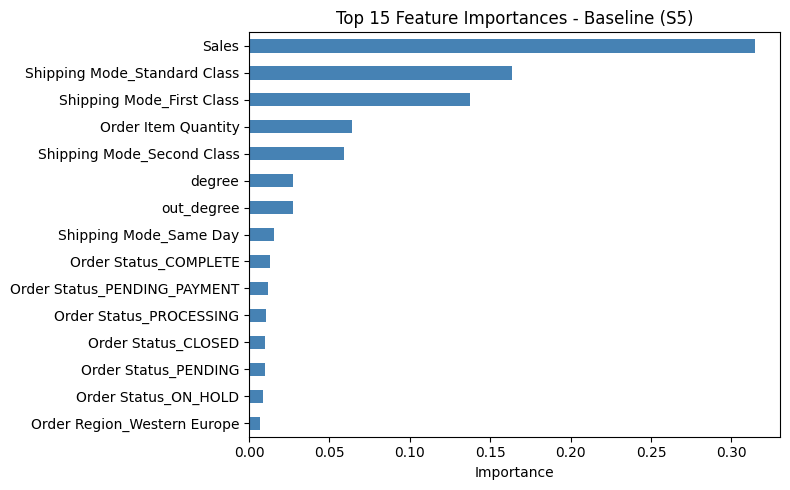

Top 5 features:
Sales                           0.314484
Shipping Mode_Standard Class    0.163802
Shipping Mode_First Class       0.137562
Order Item Quantity             0.064239
Shipping Mode_Second Class      0.058997
dtype: float64


In [17]:
clf      = baseline_pipe.named_steps["classifier"]
ohe_cols = list(
    baseline_pipe.named_steps["preprocessor"]
                 .named_transformers_["cat"]
                 .get_feature_names_out(categorical_cols_base)
)

feat_names  = numeric_cols_base + ohe_cols
importances = pd.Series(clf.feature_importances_, index=feat_names)
top15       = importances.sort_values(ascending=False).head(15)

top15.plot(kind="barh", figsize=(8, 5), color="steelblue")
plt.title("Top 15 Feature Importances - Baseline (S5)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(top15.head())

---
## PHASE 2 — S6 GRAPH-DERIVED FEATURE ENRICHMENT


## Step 10 - Load GDS Features

In [18]:
# graph_features.csv was exported by 03_graph_analytics.ipynb
# columns: order_id | pagerank | community

graph_df = pd.read_csv(f"{CLEAN_OUTPUT_DIR}/graph_features.csv")

print("GDS features shape:", graph_df.shape)
graph_df.head()

GDS features shape: (65752, 6)


,order_id,degree,out_degree,in_degree,pagerank,community
0,77202,4,3,1,0.731489,13067
1,75939,4,3,1,0.727068,13067
2,75938,4,3,1,0.727068,13067
3,75937,4,3,1,0.726586,13067
4,75936,4,3,1,0.726586,13067


## Step 11 - Merge GDS Features into the Baseline Matrix

`how='left'` is non-negotiable — it keeps every row from the S5 matrix so before/after sample sizes match.
An inner join would silently drop isolated nodes and the comparison would be invalid.

In [19]:
s5_matrix = pd.read_parquet(f"{CLEAN_OUTPUT_DIR}/baseline_feature_matrix.parquet")

# Align merge key types
s5_matrix["Order Id"]  = s5_matrix["Order Id"].astype(str)
graph_df["order_id"]   = graph_df["order_id"].astype(str)

print("S5 baseline matrix shape:", s5_matrix.shape)
s5_matrix.head(3)

S5 baseline matrix shape: (114187, 10)


,Sales,Order Item Quantity,degree,out_degree,in_degree,Shipping Mode,Order Region,Order Status,Order Id,late_delivery
0,327.75,1,4,3,1,Standard Class,Southeast Asia,COMPLETE,77202,0
1,327.75,1,4,3,1,Standard Class,Oceania,COMPLETE,75937,0
2,327.75,1,4,3,1,Standard Class,Oceania,PENDING_PAYMENT,75936,0


In [20]:
ml_df_enr = s5_matrix.merge(
    graph_df[["order_id", "pagerank", "community"]],
    how="left",
    left_on="Order Id",
    right_on="order_id"
)

ml_df_enr = ml_df_enr.drop(columns=["order_id"], errors="ignore")

# pagerank -> fill 0.0 (isolated node has zero structural importance)
ml_df_enr["pagerank"]  = ml_df_enr["pagerank"].fillna(0.0)

# community -> fill -1 sentinel, cast to string (label, not number)
ml_df_enr["community"] = ml_df_enr["community"].fillna(-1).astype(int).astype(str)

print("S5 baseline rows:", s5_matrix.shape[0])
print("Enriched rows   :", ml_df_enr.shape[0])   # must match

ml_df_enr[["Order Id", "pagerank", "community"]].head()

S5 baseline rows: 114187
Enriched rows   : 114187


,Order Id,pagerank,community
0,77202,0.731489,13067
1,75937,0.726586,13067
2,75936,0.726586,13067
3,75935,0.726586,13067
4,75934,0.731090,13067


In [21]:
# Verify enriched matrix has correct columns
# No degree_x/degree_y collision because we merged onto s5_matrix, not raw ml_df

print("Enriched matrix columns:", ml_df_enr.columns.tolist())
print("Enriched matrix shape  :", ml_df_enr.shape)

Enriched matrix columns: ['Sales', 'Order Item Quantity', 'degree', 'out_degree', 'in_degree', 'Shipping Mode', 'Order Region', 'Order Status', 'Order Id', 'late_delivery', 'pagerank', 'community']
Enriched matrix shape  : (114187, 12)


## Step 12 - Define Enriched Feature Matrix

`pagerank` is numeric — added to numeric_cols.
`community` is categorical — Louvain returns integers but they are LABELS, not quantities.
It goes into categorical_cols with OneHotEncoder, NOT into numeric_cols with StandardScaler.

In [22]:
# Add GDS columns to the respective lists
numeric_cols_enriched = numeric_cols_base + ["pagerank"]         # new from S6
categorical_cols_enriched = categorical_cols_base + ["community"] # new from S6 - label, not number

X_enriched = ml_df_enr[numeric_cols_enriched + categorical_cols_enriched].copy()
y_enr      = ml_df_enr[TARGET]

X_enriched.index = ml_df_enr["Order Id"]

print("X_enriched shape:", X_enriched.shape)

X_enriched shape: (114187, 10)


In [23]:
# Same split parameters — same random_state and stratify for a fair comparison
X_train_enr, X_test_enr, y_train_enr, y_test_enr = train_test_split(
    X_enriched,
    y_enr,
    test_size=0.2,
    stratify=y_enr,
    random_state=42
)

for col in categorical_cols_enriched:
    X_train_enr[col] = X_train_enr[col].fillna("Unknown").astype(str)
    X_test_enr[col]  = X_test_enr[col].fillna("Unknown").astype(str)

print("Train:", X_train_enr.shape)
print("Test :", X_test_enr.shape)

Train: (91349, 10)
Test : (22838, 10)


## Step 13 - Re-train the Same Pipeline with Enriched Columns

In [24]:
# Same Pipeline shape — just wider column lists
preprocessor_enriched = ColumnTransformer([
    ("num", StandardScaler(),                       numeric_cols_enriched),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols_enriched),
])

enriched_pipe = Pipeline([
    ("preprocessor", preprocessor_enriched),
    ("classifier",   RandomForestClassifier(n_estimators=200, random_state=42)),
])

enriched_pipe.fit(X_train_enr, y_train_enr)

print("Enriched pipeline trained.")

Enriched pipeline trained.


## Step 14 - Enriched Results (S6 — + pagerank + community)

In [25]:
print("=== ENRICHED (S6: + pagerank + community) ===")
print(classification_report(y_test_enr, enriched_pipe.predict(X_test_enr)))

=== ENRICHED (S6: + pagerank + community) ===
              precision    recall  f1-score   support

           0       0.77      0.82      0.80      9742
           1       0.86      0.81      0.84     13096

    accuracy                           0.82     22838
   macro avg       0.82      0.82      0.82     22838
weighted avg       0.82      0.82      0.82     22838



## Step 15 - Before / After Metric Table

This is the climax of the capstone arc — did graph analytics earn its place in the pipeline?

Metrics are computed from the actual model output, not hardcoded.
A small lift, no lift, or a negative delta are each valid findings.

In [26]:
enriched_pred  = enriched_pipe.predict(X_test_enr)
enriched_proba = enriched_pipe.predict_proba(X_test_enr)[:, 1]

enriched_metrics = {
    "Accuracy":   round(accuracy_score(y_test_enr, enriched_pred), 4),
    "F1 (macro)": round(f1_score(y_test_enr, enriched_pred, average="macro"), 4),
    "AUC":        round(roc_auc_score(y_test_enr, enriched_proba), 4),
}

# Build comparison table
comparison = pd.DataFrame({
    "Baseline (S5: degree only)":          baseline_metrics,
    "Enriched (S6: +pagerank +community)": enriched_metrics,
}).T

for metric in ["Accuracy", "F1 (macro)", "AUC"]:
    baseline_val = comparison.loc["Baseline (S5: degree only)", metric]
    comparison[f"Delta {metric}"] = (comparison[metric] - baseline_val).round(4)

print(comparison.to_string())

                                     Accuracy  F1 (macro)     AUC  Delta Accuracy  Delta F1 (macro)  Delta AUC
Baseline (S5: degree only)             0.6697      0.6664  0.7398          0.0000            0.0000     0.0000
Enriched (S6: +pagerank +community)    0.8191      0.8166  0.9036          0.1494            0.1502     0.1638


## Step 16 - Accuracy Comparison Visualization

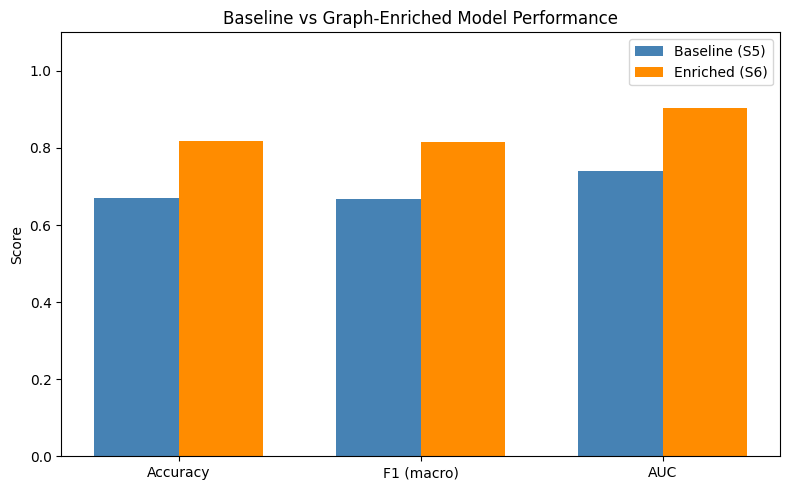

In [27]:
metrics_to_plot = ["Accuracy", "F1 (macro)", "AUC"]

baseline_vals = [baseline_metrics[m] for m in metrics_to_plot]
enriched_vals = [enriched_metrics[m] for m in metrics_to_plot]

x = range(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar([i - width/2 for i in x], baseline_vals, width, label="Baseline (S5)", color="steelblue")
ax.bar([i + width/2 for i in x], enriched_vals, width, label="Enriched (S6)", color="darkorange")

ax.set_ylabel("Score")
ax.set_title("Baseline vs Graph-Enriched Model Performance")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.show()

## Step 17 - Feature Importances (Enriched Model)

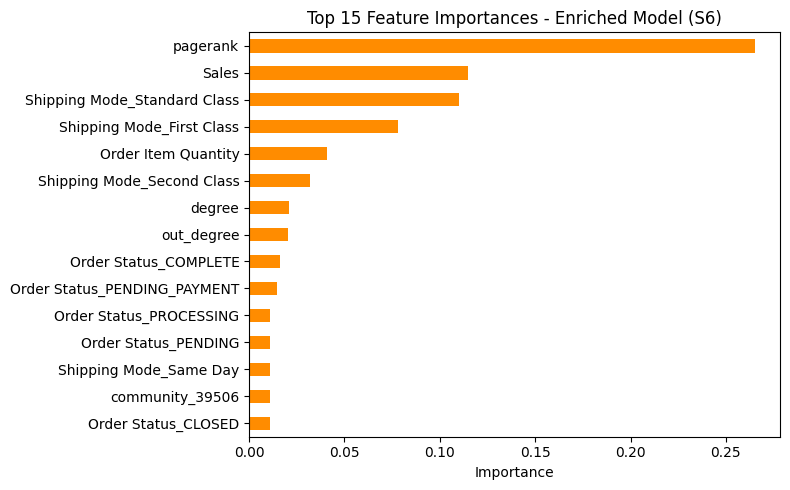

Top 5 features:
pagerank                        0.265096
Sales                           0.114574
Shipping Mode_Standard Class    0.110196
Shipping Mode_First Class       0.078094
Order Item Quantity             0.040686
dtype: float64


In [28]:
clf_e      = enriched_pipe.named_steps["classifier"]
ohe_cols_e = list(
    enriched_pipe.named_steps["preprocessor"]
                  .named_transformers_["cat"]
                  .get_feature_names_out(categorical_cols_enriched)
)

feat_names_e  = numeric_cols_enriched + ohe_cols_e
importances_e = pd.Series(clf_e.feature_importances_, index=feat_names_e)
top15_e       = importances_e.sort_values(ascending=False).head(15)

top15_e.plot(kind="barh", figsize=(8, 5), color="darkorange")
plt.title("Top 15 Feature Importances - Enriched Model (S6)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 5 features:")
print(top15_e.head())

## Step 18 - Save Predictions for Notebook 05 (Embeddings)

Notebook 05 uses `predicted_risk` and `predicted_proba` as payload fields in the Qdrant upsert.

In [29]:
df_preds = ml_df_enr[["Order Id", "late_delivery"]].copy()
df_preds["predicted_risk"]  = enriched_pipe.predict(X_enriched.fillna(0))
df_preds["predicted_proba"] = enriched_pipe.predict_proba(X_enriched.fillna(0))[:, 1]

df_preds.to_csv(
    f"{CLEAN_OUTPUT_DIR}/ml_predictions.csv",
    index=False
)

print("ml_predictions.csv saved - shape:", df_preds.shape)
df_preds.head()

ml_predictions.csv saved - shape: (114187, 4)


,Order Id,late_delivery,predicted_risk,predicted_proba
0,77202,0,1,0.513245
1,75937,0,0,0.476362
2,75936,0,0,0.196789
3,75935,1,0,0.476190
4,75934,1,1,1.000000


In [30]:
import joblib

os.makedirs("models", exist_ok=True)

# Save baseline pipeline (S5 — degree features only)
joblib.dump(baseline_pipe, "models/baseline_pipeline.joblib")
print("baseline_pipeline.joblib saved.")

# Save enriched pipeline (S6 — degree + pagerank + community)
joblib.dump(enriched_pipe, "models/enriched_pipeline.joblib")
print("enriched_pipeline.joblib saved.")

baseline_pipeline.joblib saved.
enriched_pipeline.joblib saved.


In [31]:
import json as _json

os.makedirs("reports", exist_ok=True)

# Save metrics to JSON for the Final Presentation slide
with open("reports/baseline_metrics.json", "w") as f:
    _json.dump(baseline_metrics, f, indent=2)

with open("reports/enriched_metrics.json", "w") as f:
    _json.dump(enriched_metrics, f, indent=2)

print("baseline_metrics.json saved :", baseline_metrics)
print("enriched_metrics.json saved :", enriched_metrics)

# Save enriched matrix as parquet — Streamlit loads this directly
ml_df_enr.to_parquet(
    f"{CLEAN_OUTPUT_DIR}/ml_enriched.parquet",
    index=False
)
print("ml_enriched.parquet saved - shape:", ml_df_enr.shape)

baseline_metrics.json saved : {'Accuracy': 0.6697, 'F1 (macro)': 0.6664, 'AUC': 0.7398}
enriched_metrics.json saved : {'Accuracy': 0.8191, 'F1 (macro)': 0.8166, 'AUC': 0.9036}
ml_enriched.parquet saved - shape: (114187, 12)


In [32]:
print("=" * 55)
print("FILES PRODUCED BY NOTEBOOK 04")
print("=" * 55)
print()
print(f"  {CLEAN_OUTPUT_DIR}/ml_predictions.csv        <- enriched predictions (NB05)")
print(f"  {CLEAN_OUTPUT_DIR}/baseline_predictions.csv  <- baseline predictions (Streamlit)")
print(f"  {CLEAN_OUTPUT_DIR}/baseline_feature_matrix.parquet")
print(f"  {CLEAN_OUTPUT_DIR}/ml_enriched.parquet")
print()
print("  models/baseline_pipeline.joblib  <- Streamlit: load + predict")
print("  models/enriched_pipeline.joblib  <- Streamlit: load + predict")
print()
print("  reports/baseline_metrics.json    <- Final Presentation slide")
print("  reports/enriched_metrics.json    <- Final Presentation slide")

FILES PRODUCED BY NOTEBOOK 04

  data/clean/ml_predictions.csv        <- enriched predictions (NB05)
  data/clean/baseline_predictions.csv  <- baseline predictions (Streamlit)
  data/clean/baseline_feature_matrix.parquet
  data/clean/ml_enriched.parquet

  models/baseline_pipeline.joblib  <- Streamlit: load + predict
  models/enriched_pipeline.joblib  <- Streamlit: load + predict

  reports/baseline_metrics.json    <- Final Presentation slide
  reports/enriched_metrics.json    <- Final Presentation slide


In [33]:
driver.close()

print("Notebook 04 complete.")
print("Before/after metric table above is the headline of the Final Presentation graph-analytics slide.")

Notebook 04 complete.
Before/after metric table above is the headline of the Final Presentation graph-analytics slide.
